# Background on data and methods

## Attribution

This notebook is heavily based on data and code shared for the ISIE-SEM Summer School 2026, a three-day side event of the ISIE-SEM 2026 conference.

- ISIE: the [International Society for Industrial Ecology](https://is4ie.org/);
- ISIE-SEM: the [Socio-Economic Metabolism section](https://is4ie.org/sections/metabolism) of ISIE.

This course was organised by Rick Lupton (Uni Bath, UK), Zhi Cao (Nankai University, China), and Stefan Pauliuk (University of Freiburg, Germany). Its repository is available on [Github](https://github.com/jerrysong0128/ISIE-SEM_Summer_School_2026/tree/main) under a [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/) licence.

In this notebook, we start by loading data that can be generated from the summer school's `Bath_dMFA_2026_Software_3_SampleSolution.ipynb` notebook. We then add additional dimensions to the loaded dictionary based on the `Bath_dMFA_2026_Software_5_SampleSolution.ipynb` notebook. Much of the data, its structure, and the basics of how it is manipulated are all copied directly from the summer school's repository. We also used this work in formulating the explanation of the underlying theory, provided below.

## Obtain initial data set

In [1]:
# First, import required libraries:
import pandas as pd   # dataframe library, used for fast import/export from/to excel and for organizing the data.
import numpy as np    # math library
import scipy # library with statistical functions
import matplotlib.pyplot as plt  # plotting library
from cycler import cycler
import pickle

Load `ISIE_SEM_2026_summer_school_dMFA_Results.pkl`. This file is identical to `Bath_dMFA_2026_Software_3_Results.pkl` created when following the original repository.

In [2]:
with open('ISIE_SEM_2026_summer_school_dMFA_Results.pkl', 'rb') as f:
    DynFleetResults = pickle.load(f) # deserialize using load()

for k in DynFleetResults:
    print(k, DynFleetResults[k].shape)

I_Veh_cT (71, 2)
S_Veh_tcT (71, 71, 2)
O_Veh_tcT (71, 71, 2)


Because of our application for LCA, we'd ideally have a timeline extending to when all vehicles have reached end-of-life. Because lifetimes are assumed to follow a normal distribution, the stock remaining from a cohort never fully becomes zero. Therefore, we let the original lifetime assumptions play out for another nineteen years, before artificially retiring all remaining stock in the twentieth year.

In [3]:
# Add 20 years' worth of zeroes (inflows will remain zeros; outflow and stock will change)
t_original = 71
t_extra = 20
t_total = t_original + t_extra

I_Veh_cT = np.pad(DynFleetResults['I_Veh_cT'], ((0, t_extra), (0, 0)), mode='constant', constant_values=0)
S_Veh_tcT = np.pad(DynFleetResults['S_Veh_tcT'], ((0, t_extra), (0, t_extra), (0, 0)), mode='constant', constant_values=0)
O_Veh_tcT = np.pad(DynFleetResults['O_Veh_tcT'], ((0, t_extra), (0, t_extra), (0, 0)), mode='constant', constant_values=0)

In [4]:
# Get probability distribution
Lifetime_T = np.array([[16],[13]])
pdf = scipy.stats.norm.pdf(np.arange(0,t_total,1), Lifetime_T, 0.3*Lifetime_T)

# Use balancing equations to adjust outflows and stocks for 9 years
for year in range(t_original,t_total-1): # for the additional years
    # Preparation: Forward last year's stock to this year:
    S_Veh_tcT[year,:,:] = S_Veh_tcT[year-1,:,:]
    for drivetech in range(0,2):       # for all drive technologies
        # First, the vehicle ageing: calculate the outflow of the existing stock according to the lifetime model:
        veleave_t_c = np.zeros((t_total))   # empty cohort-specific outflow container for this year
        for age_cohort in range(0,year +1): # for all inflow years till year (need to add 1 since Python stops counting 1 place before the right boundary)
            # Calculate leaving vehicles in given year, for the different age-cohorts:
            veleave_t_c[age_cohort] = I_Veh_cT[age_cohort,drivetech] * pdf[drivetech,year-age_cohort]
        # Second: Add the leaving vehicles to outflow matrix and remove them from stock
        S_Veh_tcT[year,:,drivetech] -= veleave_t_c # remove leaving vehicles in place
        O_Veh_tcT[year,:,drivetech] += veleave_t_c # add leaving vehicles in place  

# Artificially retire remaining stock in last year
year = t_total-1
for drivetech in range(0,2):
    S_Veh_tcT[year,:,drivetech] = np.zeros((t_total))
    O_Veh_tcT[year,:,drivetech] = S_Veh_tcT[year-1,:,drivetech]

In [5]:
DynFleetResults['I_Veh_cT'] = I_Veh_cT
DynFleetResults['S_Veh_tcT'] = S_Veh_tcT
DynFleetResults['O_Veh_tcT'] = O_Veh_tcT

for k in DynFleetResults:
    print(k, DynFleetResults[k].shape)

I_Veh_cT (91, 2)
S_Veh_tcT (91, 91, 2)
O_Veh_tcT (91, 91, 2)


To this dictionary, add dimensions for the function provided by the stock and the input of fuel for its operations. This is based on the notebook `Bath_dMFA_2026_Software_5_SampleSolution.ipynb`. The file `ISIE_SEM_2026_summer_school_dMFA_Data.xlsx` is almost identical to the file `Bath_dMFA_2026_Software_Data.xlsx` from the original repository: the only change is that the data in the 'Kilometrage' and 'Fuel_Consumption' sheets has been extended to 2075.

In [6]:
# get kilometrage data (annual, per vehicle) and calculate total km driven at each tcT
# (it is assumed that, in any given year, the kilometrage of all vehicles used in that year is the same, independent of cohort or technology)
km_t = pd.read_excel('ISIE_SEM_2026_summer_school_dMFA_Data.xlsx', sheet_name='Kilometrage', index_col=0).values.squeeze()
KM_tcT = DynFleetResults['S_Veh_tcT'] * km_t[:, None, None]

# get energy consumption data (MJ per km) and calculate total energy consumption at each tcT
# (it is assumed that the energy consumption is constant for a given technology-cohort)
mj_cT = pd.read_excel('ISIE_SEM_2026_summer_school_dMFA_Data.xlsx', sheet_name='Fuel_Consumption', index_col=0).values.squeeze()
E_tcT = DynFleetResults['S_Veh_tcT'] * mj_cT[None, :, :] * km_t[:, None, None]

# add this data to the dictionary
DynFleetResults['km_t']      = km_t
DynFleetResults['KM_tcT']    = KM_tcT
DynFleetResults['mj_cT']     = mj_cT
DynFleetResults['E_tcT']     = E_tcT

# and a timeseries (reflecting the years covered) and technology 
DynFleetResults['t']         = np.arange(1990,1990+t_total,1)
DynFleetResults['T']         = np.array(['ICEV', 'BEV'])

for k in DynFleetResults:
    print(k, DynFleetResults[k].shape)

I_Veh_cT (91, 2)
S_Veh_tcT (91, 91, 2)
O_Veh_tcT (91, 91, 2)
km_t (91,)
KM_tcT (91, 91, 2)
mj_cT (91, 2)
E_tcT (91, 91, 2)
t (91,)
T (2,)


In [7]:
# we will not make further changes for now, so store this dictionary for later
with open('dMFA_Results.pkl', 'wb') as f:  # open a text file
    pickle.dump(DynFleetResults, f) # serialize the list
f.close()

## Theoretical foundation

The approach to dynamic material flow analysis (dMFA) used here is based on stocks of cohorts. A cohort is created in a particular year and the evolution of its stock over time is described by certain lifetime characteristics. The dataset is obtained by starting from a timeseries of inflows based on historical data. These inflows, when combined with a lifetime distribution function, are used to determine stocks and outflows. This is a flow-driven approach.

The dataset is then expanded to years past the historical observations. By assuming a certain trend for the evolution of the total stock, the cohort-specific inflows and outflows can be calculated, again based on cohort lifetime distributions. This is a stock-driven approach.

### Flow-driven approach

The initial quantity of each cohort (defined by having been created at time $c$) is described by the inflow over time $I(t)$. We can then calculate the outflow $O(t,c)$ and stock $S(t,c)$ of each cohort as follows: 

$$ O(t,c) = 
    \begin{cases}
        0, & t < c \\
        I(c) \cdot pdf(t-c), & t \ge c
    \end{cases} $$

$$ S(t,c) =
    \begin{cases}
        0, & t < c \\
        I(t) - O(t,c), & t = c \\
        S(t-1,c) - O(t,c), & t > c
    \end{cases} $$

Note that these are not continuous functions. Instead, we work with discrete timesteps, so that $t+1$ is understood as the timestep following $t$. In this case, we consistently use a timestep of 1 year. The probability distribution function $pdf(t-c)$ (where $t-c$ is the age of stock $c$ at time $t$) is here described as a normal distribution, with mean lifetime $\tau$ and with a standard deviation $\sigma$:

$$ pdf(age) = \frac{1}{\sigma \sqrt{2\pi} } e^{-\frac{1}{2}\left(\frac{age-\tau}{\sigma}\right)^2} $$

The total stock $S(t)$ and outflow $O(t)$ is then defined as the sum of stocks and outflows derived from all cohorts created up to and including $t$, with $t_0$ being the first moment for which an inflow is defined:

$$ S(t) = \sum_{c=t_0}^{t} S(t,c) $$

$$ O(t) = \sum_{c=t_0}^{t} O(t,c) $$

### Stock-driven approach

For the portion of the timespan beyond the initially defined inflows, we start by defining the total stock $S(t)$. Inflows are then determined according to what it would take to realise this stock:

$$ I(t) = S(t) - \sum_{c=t_0}^{t-1} S(t,c) $$

Notice that the summation above only leads to $t-1$. The stock of cohort $c=t$ is determined by first calculating $I(t)$ from $S(t)$. By creating these cohorts year by year, the cohort-specific stocks and outflows can be calculated using the same logic of the flow-driven approach. The assumption is made in this case that cohorts obtained in this way have no throughput. I.e., for $t=c$:

$$ O(t,c) = 0 $$

$$ S(t,c) = I(t) $$

## Demonstrating the basics

Understanding this theoretical foundation, let's have a proper look at the data we're dealing with. As explained, this case is taken from the [ISIE-SEM Summer School 2026](https://github.com/jerrysong0128/ISIE-SEM_Summer_School_2026/tree/main). It concerns passenger cars in the 20 countries that formed the eurozone in 2024. This case originally focussed on a shift from ICEVs to BEVs.

Let's start by plotting the total inflow and outflow for each year. The initial, jagged section of the inflow (up to 2024) is based on historical data. From 2025 onwards, the inflow gradually declines to zero, which is based on a (stock-driven) scenario assumption that ICE vehicles are phased out due to electric vehicles being environmentally preferable. Due to the assumption that all cohorts share a particular lifetime distribution, the outflow is fairly smooth over the entire timespan. A small exception occurs in the last year, 2070, where we artificially retire the remaining vehicles so that each cohort has its full lifecycle accounted for.

The actual outflow and stock of vehicles would have looked quite different for the initial years of this timespan, as what we're showing below only considers vehicles from 1990 onwards. In reality, there were already plenty of vehicles in 1990, but these are entirely absent from these results. This isn't particularly relevant for our purposes, as long as we keep in mind that we can't accurately capture what vehicles were in use before (as a rough estimate) 2010.

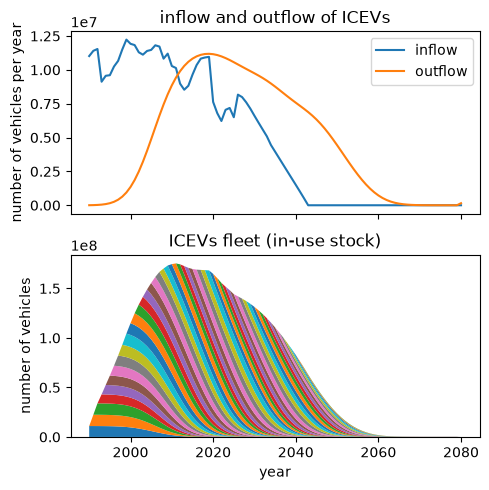

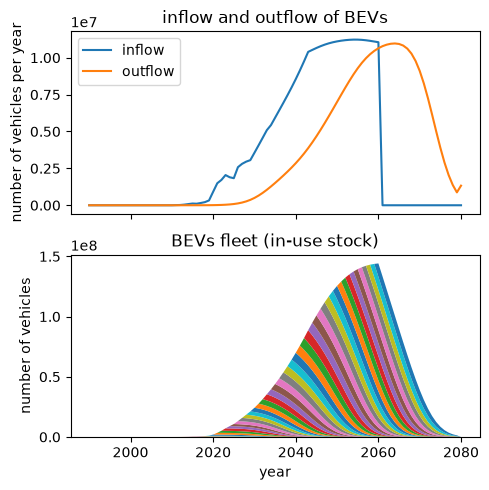

In [8]:
def show_stock_and_flows(T_index, T_label):
    fig, axs = plt.subplots(2, sharex=True, figsize=(5,5))

    axs[0].plot(DynFleetResults['t'], DynFleetResults['I_Veh_cT'][:,T_index])
    axs[0].plot(DynFleetResults['t'], np.einsum('tc->t',DynFleetResults['O_Veh_tcT'][:,:,T_index]))
    axs[0].set_title(f'inflow and outflow of {T_label}')
    #axs[0].title('note that outflow from pre-1990 stock is not modelled', fontsize='small')
    axs[0].set(ylabel='number of vehicles per year')
    axs[0].legend(['inflow','outflow'])

    axs[1].stackplot(DynFleetResults['t'],np.transpose(DynFleetResults['S_Veh_tcT'][:,:,T_index])) # plot the result
    axs[1].set_title(f'{T_label} fleet (in-use stock)')
    #axs[1].title('note that pre-1990 stock is not modelled', fontsize='small')
    axs[1].set(ylabel='number of vehicles',xlabel='year')

    plt.tight_layout()
    plt.show()

show_stock_and_flows(0, 'ICEVs')
show_stock_and_flows(1, 'BEVs')

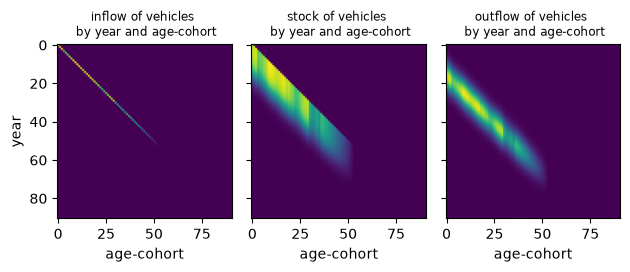

In [9]:
# for this illustration, the inflows are shown along two dimensions, but note that their actual data is stored in one dimension
fig, axs = plt.subplots(1,3, sharey=True)

axs[0].imshow(np.diag(DynFleetResults['I_Veh_cT'][:,0])) # create a simple heatmap: larger value --> brighter color.
axs[0].set_title('inflow of vehicles \n by year and age-cohort', fontsize='small')
axs[0].set(xlabel='age-cohort', ylabel='year')
axs[1].imshow(DynFleetResults['S_Veh_tcT'][:,:,0]) # create a simple heatmap: larger value --> brighter color.
axs[1].set(xlabel='age-cohort')
axs[1].set_title('stock of vehicles \n by year and age-cohort', fontsize='small')
axs[2].imshow(DynFleetResults['O_Veh_tcT'][:,:,0]) # create a simple heatmap: larger value --> brighter color.
axs[2].set(xlabel='age-cohort')
axs[2].set_title('outflow of vehicles \n by year and age-cohort', fontsize='small')

plt.tight_layout()
plt.show()

Furthermore, we can show that inflows and outflows are indeed balanced. Using `np.isclose()`, the sum of inflows is equal to the sum of outflows, which also holds for each individual cohort.

In [10]:
print(np.isclose(DynFleetResults['I_Veh_cT'].sum(), DynFleetResults['O_Veh_tcT'].sum()))
print(np.isclose(DynFleetResults['I_Veh_cT'], DynFleetResults['O_Veh_tcT'].sum(axis=0)))

True
[[ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ True  True]
 [ Tr

The scenarios we're adopting also include assumptions for the function provided by vehicles (i.e., travelling a certain distance) and the energy that vehicles consume (in the form of liquid fuel or, for BEVs, as electricity) in order to realise this function. The yearly function provided by a single car is assumed to be constant across the whole fleet that is active in a particular year. Initially, this is taken to be 14,000 km, but from 2026 onwards this increases every year. On the other hand, the energy a vehicle consumes in order to travel a particular distance depends entirely on the cohort this vehicle is part of. This way, pre-2025 ICEV cohorts consume 3 MJ per km and this value decreases for later cohorts.

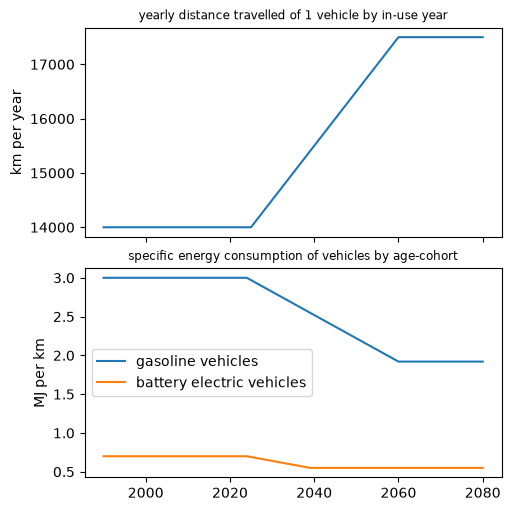

In [13]:

fig, axs = plt.subplots(2, sharex=True, figsize=(5,5), constrained_layout = True)

axs[0].plot(DynFleetResults['t'], DynFleetResults['km_t'])
axs[0].set_title('yearly distance travelled of 1 vehicle by in-use year', fontsize='small')
axs[0].set(ylabel='km per year')

axs[1].plot(DynFleetResults['t'], DynFleetResults['mj_cT'])
axs[1].legend(['gasoline vehicles','battery electric vehicles'])
axs[1].set_title('specific energy consumption of vehicles by age-cohort', fontsize='small')
axs[1].set(ylabel='MJ per km')

plt.show()

These prospective changes lead to the total distance travelled being larger than would be assumed from just examining the stock (compare green and blue lines below). The evolution of the fleet's energy consumption (orange lines) also deviates from that of the stock. This is partially because of the assumed cohort-specific improvements, but primarily attributable to the shift from ICEVs to BEVs, which consume much less energy.

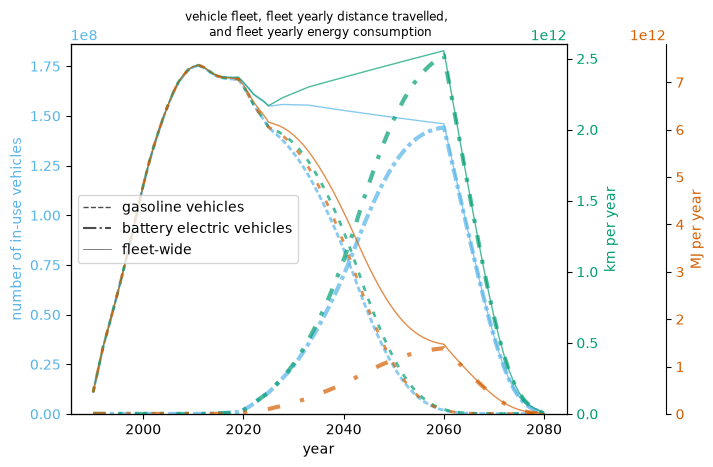

In [14]:
fig, ax = plt.subplots()

cycler1 = cycler(linestyle=[(0, (2,1)), (0, (3, 1, 1, 1)), '-'], linewidth=[2,3,1])
cycler2 = cycler(linestyle=[(0, (2,3)), (0, (3, 3, 1, 3)), '-'], linewidth=[2,3,1])
cycler3 = cycler(linestyle=[(0, (2, 5)), (0, (3, 5, 1, 5)), '-'], linewidth=[2,3,1])
color1 = '#56B4E9'
color2 = '#009E73'
color3 = '#D55E00'
alpha = 0.7

ax.set_xlabel('year')
ax.set_ylabel('number of in-use vehicles', color=color1)
ax.set_prop_cycle(cycler1)
ax.plot(DynFleetResults['t'], DynFleetResults['S_Veh_tcT'].sum(axis=1), color=color1, alpha=alpha)
ax.plot(DynFleetResults['t'], DynFleetResults['S_Veh_tcT'].sum(axis=(1,2)), color=color1, alpha=alpha)
ax.set_ylim(bottom=0.0, top=1.86e8)
ax.tick_params(axis='y', labelcolor=color1)

ax_1 = ax.twinx()
ax_1.set_ylabel('km per year', color=color2)
ax_1.set_prop_cycle(cycler2)
ax_1.plot(DynFleetResults['t'], DynFleetResults['KM_tcT'].sum(axis=1), color=color2, alpha=alpha)
ax_1.plot(DynFleetResults['t'], DynFleetResults['KM_tcT'].sum(axis=(1,2)), color=color2, alpha=alpha)
ax_1.set_ylim(bottom=0.0, top=2.6e12)
ax_1.tick_params(axis='y', labelcolor=color2)
ax_1.set_title('vehicle fleet, fleet yearly distance travelled, \n and fleet yearly energy consumption', fontsize='small')

ax_2 = ax.twinx()
ax_2.spines.right.set_position(("axes", 1.2))
ax_2.yaxis.get_offset_text().set_x(1.2)
ax_2.set_ylabel('MJ per year', color=color3)
ax_2.set_prop_cycle(cycler3)
ax_2.plot(DynFleetResults['t'], DynFleetResults['E_tcT'].sum(axis=1), color=color3, alpha=alpha)
ax_2.plot(DynFleetResults['t'], DynFleetResults['E_tcT'].sum(axis=(1,2)), color=color3, alpha=alpha)
ax_2.set_ylim(bottom=0.0, top=7.8e12)
ax_2.tick_params(axis='y', labelcolor=color3)

plt.plot([], [], color="black", linestyle="--", linewidth=2/2, alpha=alpha, label="gasoline vehicles")
plt.plot([], [], color="black", linestyle="-.", linewidth=3/2, alpha=alpha, label="battery electric vehicles")
plt.plot([], [], color="black", linestyle="-", linewidth=1/2, alpha=alpha, label="fleet-wide")
plt.legend(loc='center left')

plt.show()